# PCA: Principal Component Analysis

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.pipeline import Pipeline
import time

sns.set_style('whitegrid')
np.random.seed(42)

---
### Cargar dataset: Vinos con 13 propiedades química
---

In [28]:
wine = load_wine()
X = wine.data
y = wine.target

print(f"Forma del dataset: {X.shape}")
print(f"Cantidad de muestras: {X.shape[0]}")
print(f"Cantidad de features: {X.shape[1]}")
print(f"\nClases de vino: {wine.target_names}")
print(f"\nNombres de features:")
for i, name in enumerate(wine.feature_names, 1):
    print(f"  {i}. {name}")

Forma del dataset: (178, 13)
Cantidad de muestras: 178
Cantidad de features: 13

Clases de vino: ['class_0' 'class_1' 'class_2']

Nombres de features:
  1. alcohol
  2. malic_acid
  3. ash
  4. alcalinity_of_ash
  5. magnesium
  6. total_phenols
  7. flavanoids
  8. nonflavanoid_phenols
  9. proanthocyanins
  10. color_intensity
  11. hue
  12. od280/od315_of_diluted_wines
  13. proline


In [29]:
df = pd.DataFrame(X, columns=wine.feature_names)
df['class'] = y
df['class_name'] = df['class'].map({0: 'Clase 0', 1: 'Clase 1', 2: 'Clase 2'})

display(df.head(10))

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class,class_name
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,Clase 0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,Clase 0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,Clase 0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,Clase 0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,Clase 0
5,14.20,1.76,2.45,15.2,112.0,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450.0,0,Clase 0
6,14.39,1.87,2.45,14.6,96.0,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290.0,0,Clase 0
7,14.06,2.15,2.61,17.6,121.0,2.60,2.51,0.31,1.25,5.05,1.06,3.58,1295.0,0,Clase 0
8,14.83,1.64,2.17,14.0,97.0,2.80,2.98,0.29,1.98,5.20,1.08,2.85,1045.0,0,Clase 0
9,13.86,1.35,2.27,16.0,98.0,2.98,3.15,0.22,1.85,7.22,1.01,3.55,1045.0,0,Clase 0


---
### Análisis exploratorio
---

In [30]:
print("Estadísticas descriptivas:")
display(df.describe())

Estadísticas descriptivas:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


/var/folders/z5/hz8g2_8150x7z4zn9jgm4xjm0000gn/T/ipykernel_3641/2781160786.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='class_name', data=df, palette='Set2')


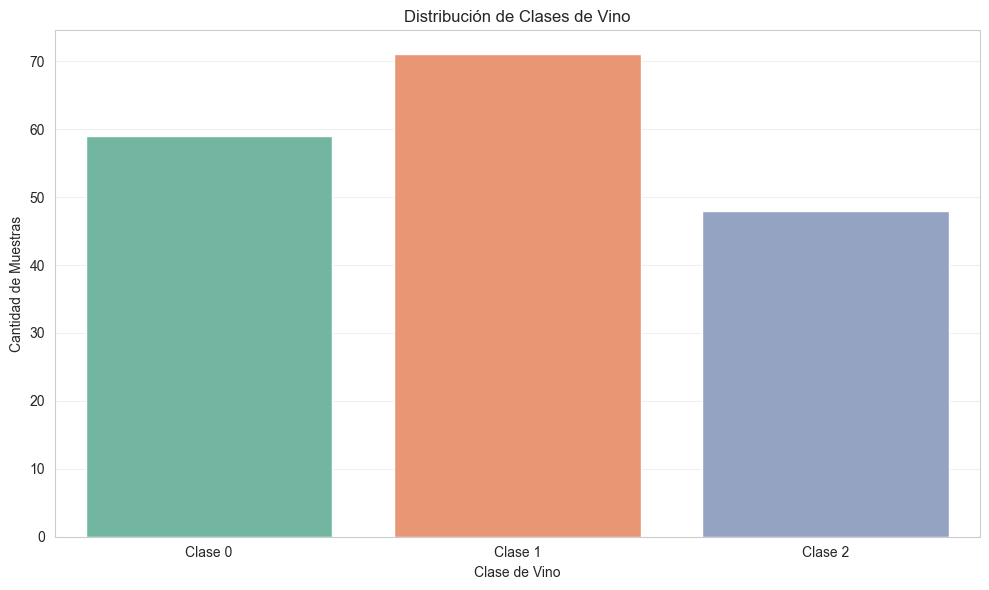

In [31]:
plt.figure(figsize=(10, 6))
sns.countplot(x='class_name', data=df, palette='Set2')
plt.xlabel('Clase de Vino')
plt.ylabel('Cantidad de Muestras')
plt.title('Distribución de Clases de Vino')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

**Observación:** El dataset está relativamente balanceado, con las 3 clases bien representadas.

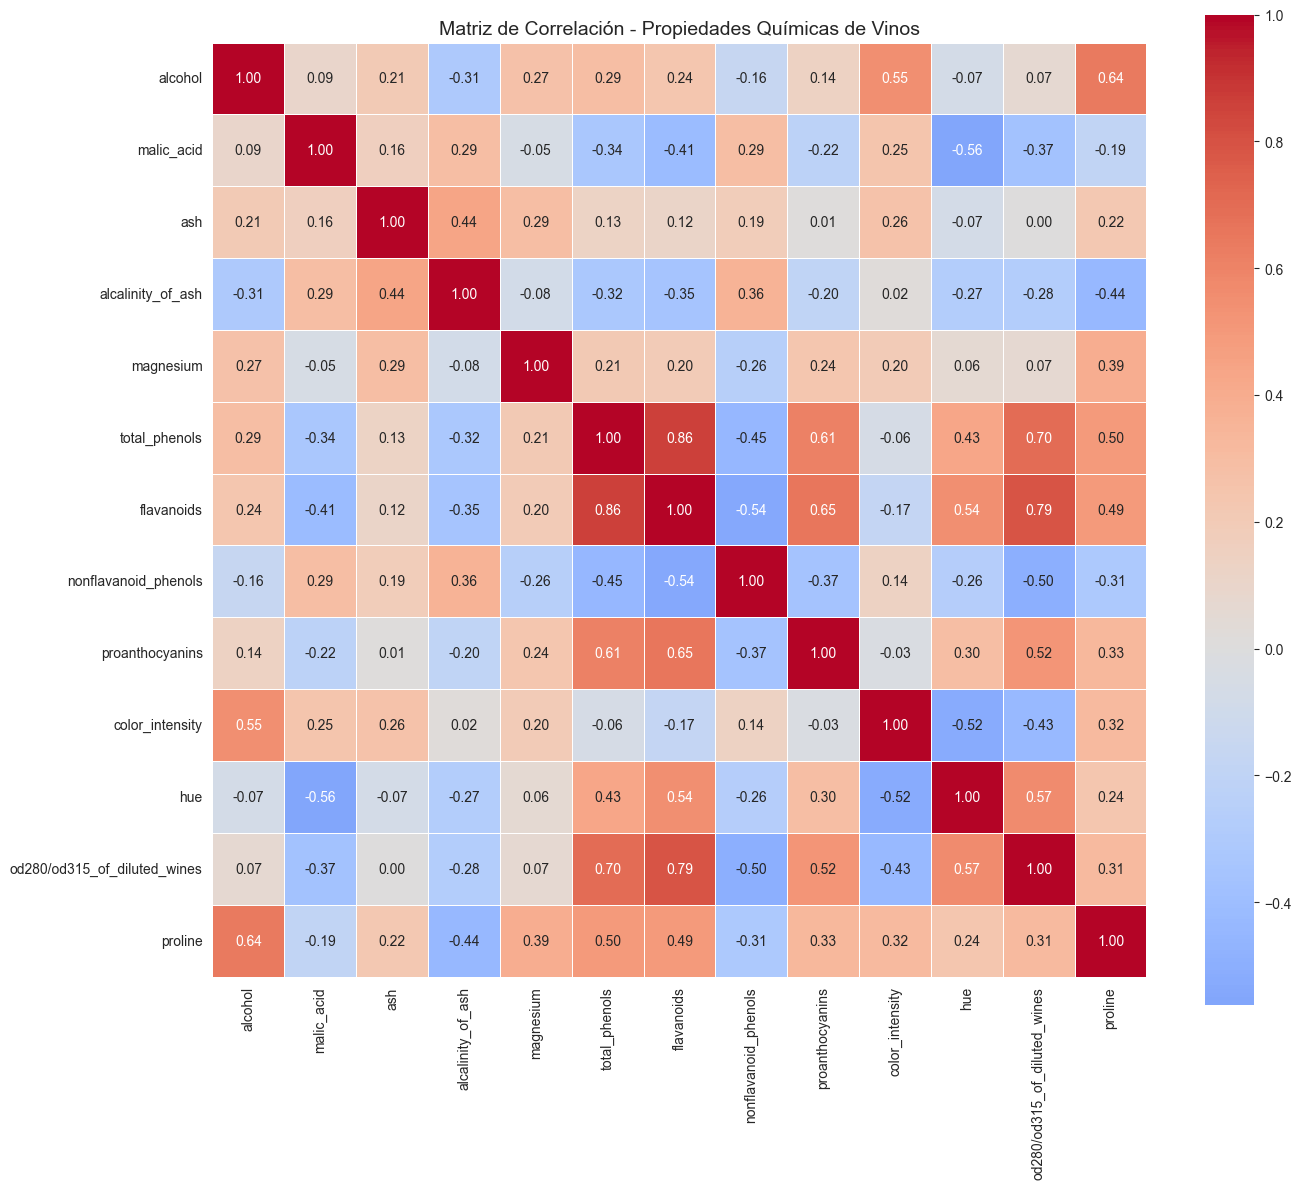

In [32]:
plt.figure(figsize=(14, 12))
correlation_matrix = df.drop(['class', 'class_name'], axis=1).corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5)
plt.title('Matriz de Correlación - Propiedades Químicas de Vinos', fontsize=14)
plt.tight_layout()
plt.show()

**Observaciones clave:**
- Hay **muchas correlaciones altas** entre features (valores cercanos a 1 o -1)
- Por ejemplo: `flavanoids` y `total_phenols` están muy correlacionadas (0.86)
- También `od280/od315_of_diluted_wines` con `flavanoids` (0.79)
- Esta redundancia es perfecta para aplicar PCA

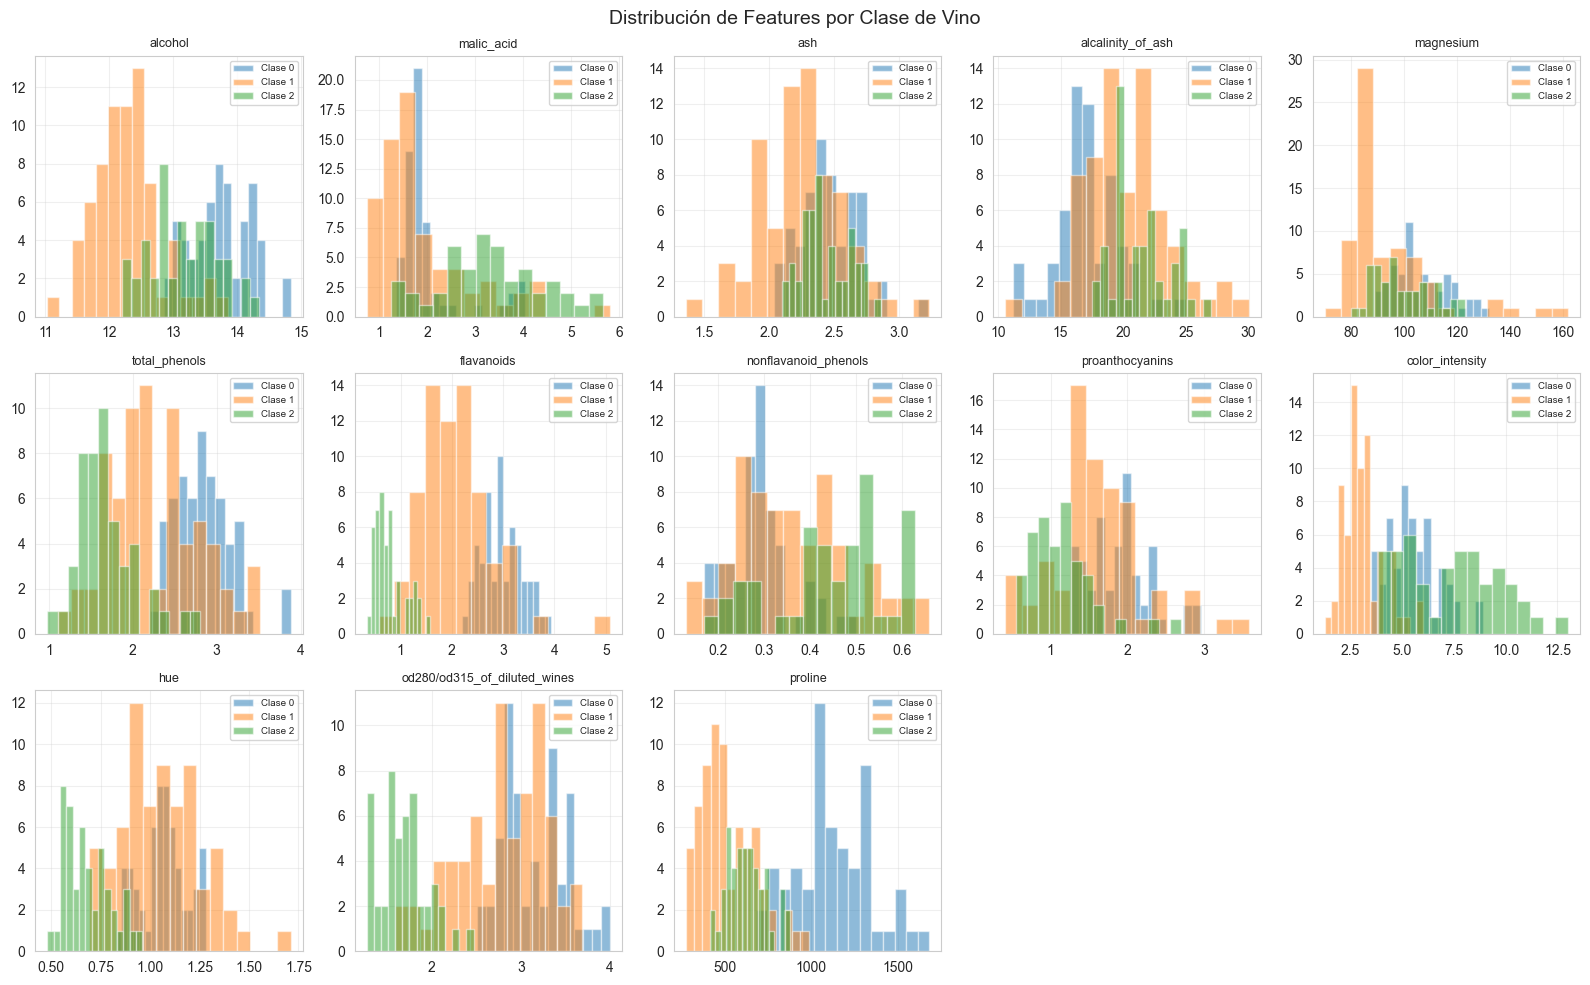

In [33]:
fig, axes = plt.subplots(3, 5, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(wine.feature_names):
    for class_idx in range(3):
        axes[i].hist(df[df['class'] == class_idx][col], 
                     alpha=0.5, label=f'Clase {class_idx}', bins=15)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('')
    axes[i].legend(fontsize=7)
    axes[i].grid(True, alpha=0.3)

axes[-2].axis('off')
axes[-1].axis('off')

plt.suptitle('Distribución de Features por Clase de Vino', fontsize=14)
plt.tight_layout()
plt.show()

**Observación:** Algunas features separan bien las clases (ej: `flavanoids`, `proline`), mientras que otras tienen mucho overlap. PCA puede ayudarnos a encontrar combinaciones que separen mejor.

---
### Estandarización de features
---

In [34]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features estandarizadas:")
print(f"Media por feature (debe ser ~0): {X_scaled.mean(axis=0)[:5]}")
print(f"Std por feature (debe ser ~1): {X_scaled.std(axis=0)[:5]}")

Features estandarizadas:
Media por feature (debe ser ~0): [ 7.84141790e-15  2.44498554e-16 -4.05917497e-15 -7.11041712e-17
 -2.49488320e-17]
Std por feature (debe ser ~1): [1. 1. 1. 1. 1.]


**¿Por qué estandarizar?**

PCA es sensible a la escala de las variables. Si una feature tiene valores entre 0-1000 y otra entre 0-1, la primera va a dominar completamente la varianza, aunque no sea la más importante.

Estandarizar (media=0, std=1) pone todas las features en igualdad de condiciones.

---
### Aplicar PCA con todos los componentes
---

In [35]:
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

print(f"Cantidad de componentes principales: {pca_full.n_components_}")
print(f"\nVarianza explicada por cada componente:")
for i in range(pca_full.n_components_):
    print(f"PC{i+1}: {pca_full.explained_variance_ratio_[i]:.4f} ({pca_full.explained_variance_ratio_[i]*100:.2f}%)")

Cantidad de componentes principales: 13

Varianza explicada por cada componente:
PC1: 0.3620 (36.20%)
PC2: 0.1921 (19.21%)
PC3: 0.1112 (11.12%)
PC4: 0.0707 (7.07%)
PC5: 0.0656 (6.56%)
PC6: 0.0494 (4.94%)
PC7: 0.0424 (4.24%)
PC8: 0.0268 (2.68%)
PC9: 0.0222 (2.22%)
PC10: 0.0193 (1.93%)
PC11: 0.0174 (1.74%)
PC12: 0.0130 (1.30%)
PC13: 0.0080 (0.80%)


**Observación:** Los primeros componentes capturan MUCHA más varianza que los últimos. Por ejemplo, PC1 captura ~36%, mientras que PC13 solo ~0.8%.

---
### Varianza explicada: ¿Cuántos componentes necesitamos?
---

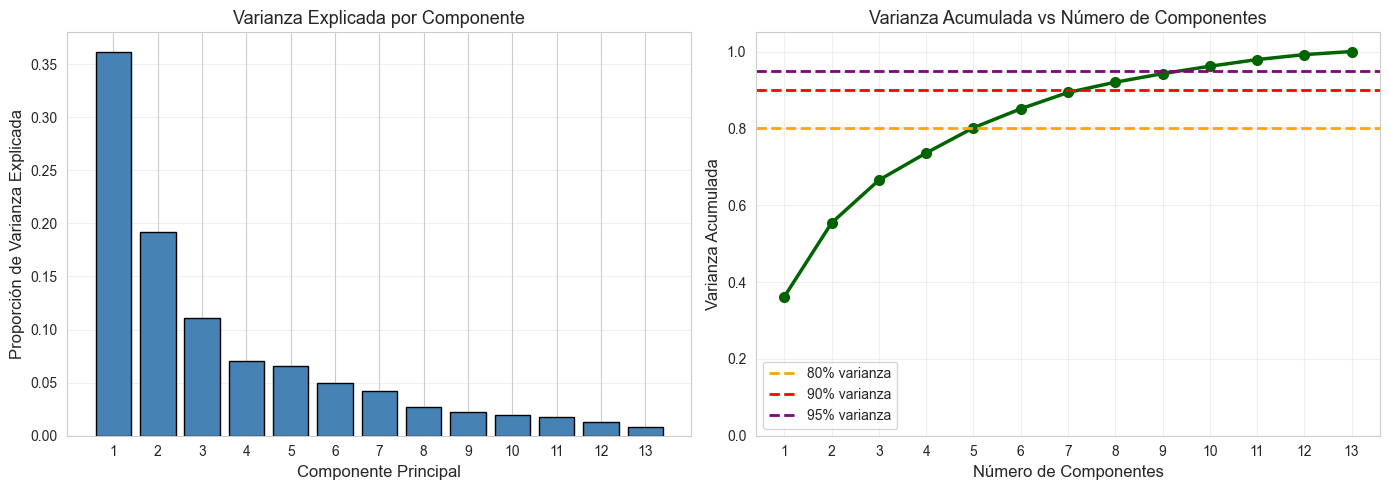

Componentes necesarios para 80% varianza: 5
Componentes necesarios para 90% varianza: 8
Componentes necesarios para 95% varianza: 10


In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Varianza explicada por componente
axes[0].bar(range(1, len(pca_full.explained_variance_ratio_) + 1), 
            pca_full.explained_variance_ratio_, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Componente Principal', fontsize=12)
axes[0].set_ylabel('Proporción de Varianza Explicada', fontsize=12)
axes[0].set_title('Varianza Explicada por Componente', fontsize=13)
axes[0].set_xticks(range(1, 14))
axes[0].grid(True, alpha=0.3, axis='y')

# Varianza acumulada
varianza_acumulada = np.cumsum(pca_full.explained_variance_ratio_)
axes[1].plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, 
             marker='o', linewidth=2.5, markersize=7, color='darkgreen')
axes[1].axhline(y=0.80, color='orange', linestyle='--', linewidth=2, label='80% varianza')
axes[1].axhline(y=0.90, color='red', linestyle='--', linewidth=2, label='90% varianza')
axes[1].axhline(y=0.95, color='purple', linestyle='--', linewidth=2, label='95% varianza')
axes[1].set_xlabel('Número de Componentes', fontsize=12)
axes[1].set_ylabel('Varianza Acumulada', fontsize=12)
axes[1].set_title('Varianza Acumulada vs Número de Componentes', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(range(1, 14))
axes[1].set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

for threshold in [0.80, 0.90, 0.95]:
    n_components = np.argmax(varianza_acumulada >= threshold) + 1
    print(f"Componentes necesarios para {threshold*100:.0f}% varianza: {n_components}")

**Conclusión importante:**

Con solo **2 componentes** capturamos el 55% de la varianza, con **3 componentes** el 66%, y con **5 componentes** ya llegamos al 80%.

Esto significa que podemos reducir de **13 features a 5 componentes** y mantener el 80% de la información. ¡Una reducción del 62%!

---
### Visualización en 2D: Reducir 13 dimensiones a 2
---

In [37]:
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

print(f"Forma original: {X_scaled.shape}")
print(f"Forma reducida (2D): {X_pca_2d.shape}")
print(f"\nVarianza explicada con 2 componentes: {pca_2d.explained_variance_ratio_.sum():.4f} ({pca_2d.explained_variance_ratio_.sum()*100:.2f}%)")
print(f"  - PC1: {pca_2d.explained_variance_ratio_[0]:.4f} ({pca_2d.explained_variance_ratio_[0]*100:.2f}%)")
print(f"  - PC2: {pca_2d.explained_variance_ratio_[1]:.4f} ({pca_2d.explained_variance_ratio_[1]*100:.2f}%)")

Forma original: (178, 13)
Forma reducida (2D): (178, 2)

Varianza explicada con 2 componentes: 0.5541 (55.41%)
  - PC1: 0.3620 (36.20%)
  - PC2: 0.1921 (19.21%)


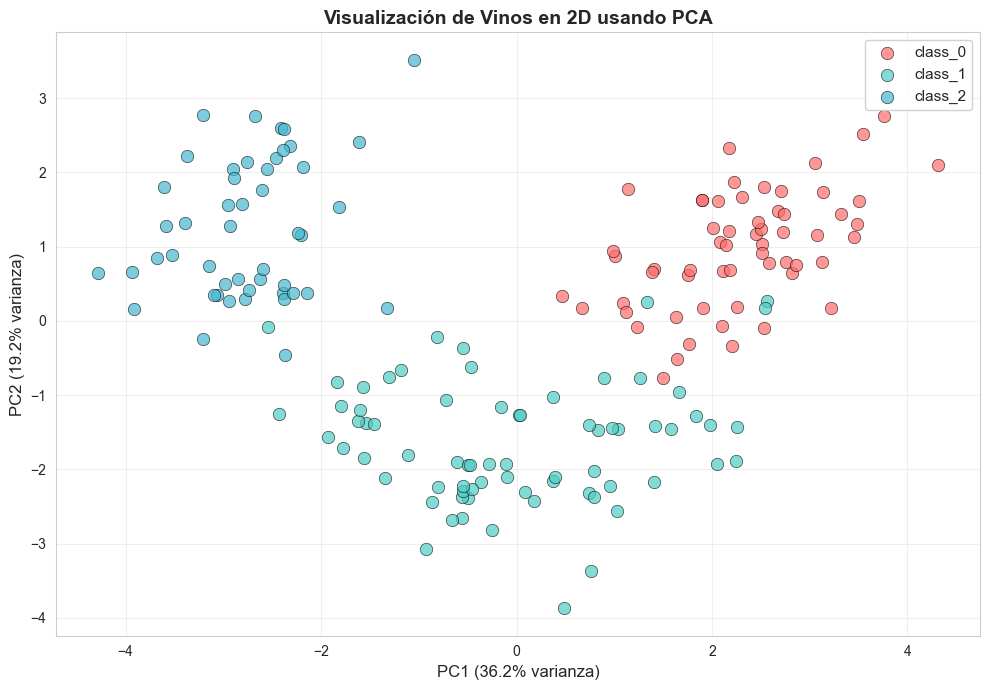

In [38]:
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
class_names = wine.target_names

plt.figure(figsize=(10, 7))
for i, color in enumerate(colors):
    mask = y == i
    plt.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1], 
                c=color, label=f'{class_names[i]}', 
                alpha=0.7, edgecolors='black', s=80, linewidth=0.5)

plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% varianza)', fontsize=12)
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% varianza)', fontsize=12)
plt.title('Visualización de Vinos en 2D usando PCA', fontsize=14, weight='bold')
plt.legend(fontsize=11, framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Observación clave:**

¡Ahora podemos ver datos de 13 dimensiones en 2D! Las 3 clases de vino se separan bastante bien:
- La clase 0 (rojo) está claramente separada en la parte negativa de PC1
- Las clases 1 y 2 (turquesa y azul) tienen algo de overlap pero también se distinguen

Esto sugiere que las 2 primeras componentes principales capturan la información discriminatoria entre clases.

---
### Interpretación de componentes principales: ¿Qué representan?
---

In [39]:
components_df = pd.DataFrame(
    pca_2d.components_.T,
    columns=['PC1', 'PC2'],
    index=wine.feature_names
)

print("Contribución de cada feature a los componentes principales:")
print("(Valores más altos en magnitud = mayor contribución)\n")
display(components_df.style.background_gradient(cmap='RdBu_r', axis=0))

Contribución de cada feature a los componentes principales:
(Valores más altos en magnitud = mayor contribución)



,PC1,PC2
alcohol,0.144329,0.483652
malic_acid,-0.245188,0.224931
ash,-0.002051,0.316069
alcalinity_of_ash,-0.239320,-0.010591
magnesium,0.141992,0.299634
total_phenols,0.394661,0.065040
flavanoids,0.422934,-0.003360
nonflavanoid_phenols,-0.298533,0.028779
proanthocyanins,0.313429,0.039302
color_intensity,-0.088617,0.529996


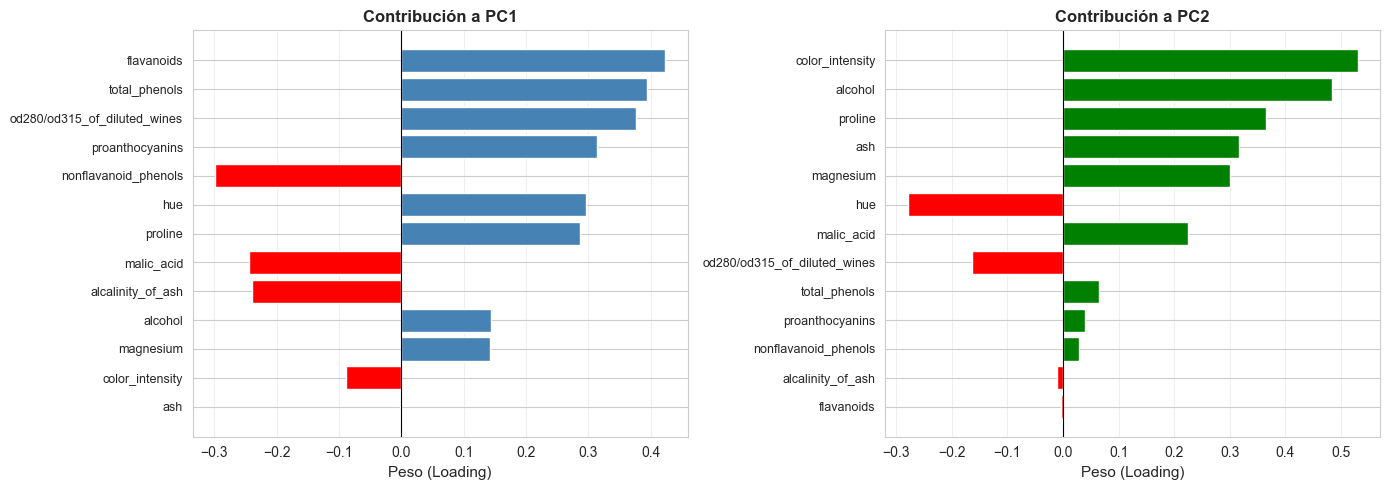

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PC1
pc1_sorted = components_df['PC1'].abs().sort_values(ascending=True)
colors_pc1 = ['red' if x < 0 else 'steelblue' for x in components_df.loc[pc1_sorted.index, 'PC1']]
axes[0].barh(range(len(pc1_sorted)), components_df.loc[pc1_sorted.index, 'PC1'], color=colors_pc1)
axes[0].set_yticks(range(len(pc1_sorted)))
axes[0].set_yticklabels(pc1_sorted.index, fontsize=9)
axes[0].set_xlabel('Peso (Loading)', fontsize=11)
axes[0].set_title('Contribución a PC1', fontsize=12, weight='bold')
axes[0].axvline(x=0, color='black', linewidth=0.8)
axes[0].grid(True, alpha=0.3, axis='x')

# PC2
pc2_sorted = components_df['PC2'].abs().sort_values(ascending=True)
colors_pc2 = ['red' if x < 0 else 'green' for x in components_df.loc[pc2_sorted.index, 'PC2']]
axes[1].barh(range(len(pc2_sorted)), components_df.loc[pc2_sorted.index, 'PC2'], color=colors_pc2)
axes[1].set_yticks(range(len(pc2_sorted)))
axes[1].set_yticklabels(pc2_sorted.index, fontsize=9)
axes[1].set_xlabel('Peso (Loading)', fontsize=11)
axes[1].set_title('Contribución a PC2', fontsize=12, weight='bold')
axes[1].axvline(x=0, color='black', linewidth=0.8)
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

**Interpretación:**

**PC1** (36% de la varianza):
- Está fuertemente influenciada por `flavanoids`, `total_phenols`, `od280/od315_of_diluted_wines` y `proline`
- Podríamos interpretarla como un eje de "compuestos fenólicos y calidad del vino"

**PC2** (19% de la varianza):
- Está más influenciada por `color_intensity`, `proline`, y `alcohol`
- Podríamos interpretarla como un eje de "intensidad de color y contenido alcohólico"

Estas interpretaciones son aproximadas - los componentes son combinaciones complejas de todas las features.

---
### Visualización en 3D
---

In [41]:
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

print(f"Varianza explicada con 3 componentes: {pca_3d.explained_variance_ratio_.sum():.4f} ({pca_3d.explained_variance_ratio_.sum()*100:.2f}%)")
print(f"  - PC1: {pca_3d.explained_variance_ratio_[0]:.4f} ({pca_3d.explained_variance_ratio_[0]*100:.2f}%)")
print(f"  - PC2: {pca_3d.explained_variance_ratio_[1]:.4f} ({pca_3d.explained_variance_ratio_[1]*100:.2f}%)")
print(f"  - PC3: {pca_3d.explained_variance_ratio_[2]:.4f} ({pca_3d.explained_variance_ratio_[2]*100:.2f}%)")

Varianza explicada con 3 componentes: 0.6653 (66.53%)
  - PC1: 0.3620 (36.20%)
  - PC2: 0.1921 (19.21%)
  - PC3: 0.1112 (11.12%)


In [49]:
import plotly.graph_objs as go
import plotly.express as px

# Creamos un DataFrame para usar con plotly
import pandas as pd

pca_3d_df = pd.DataFrame(X_pca_3d, columns=['PC1', 'PC2', 'PC3'])
pca_3d_df['Clase'] = y
pca_3d_df['ClaseNombre'] = [class_names[c] for c in y]

# Usamos plotly express para el gráfico interactivo
fig = px.scatter_3d(
    pca_3d_df,
    x='PC1',
    y='PC2',
    z='PC3',
    color='ClaseNombre',
    labels={
        'PC1': f'PC1 ({pca_3d.explained_variance_ratio_[0]*100:.1f}% var)',
        'PC2': f'PC2 ({pca_3d.explained_variance_ratio_[1]*100:.1f}% var)',
        'PC3': f'PC3 ({pca_3d.explained_variance_ratio_[2]*100:.1f}% var)',
    },
    title='Visualización 3D de Vinos usando PCA (Interactivo)',
    opacity=0.7
)
fig.update_traces(marker=dict(size=6, line=dict(width=0.5, color='black')))
fig.update_layout(
    legend_title_text='Clase',
    width=1000,
    height=700,
)
fig.show()

**Observación:** Con 3 componentes (66% de la varianza) las clases se separan aún mejor. La tercera dimensión ayuda a distinguir casos que se solapaban en 2D.

---
### PCA + Machine Learning: ¿Mejora el performance?
---

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Conjunto de entrenamiento: {X_train.shape}")
print(f"Conjunto de prueba: {X_test.shape}")

Conjunto de entrenamiento: (124, 13)
Conjunto de prueba: (54, 13)


In [44]:
print("="*70)
print("MODELO SIN PCA (13 features)")
print("="*70)

pipeline_sin_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=5000, random_state=42))
])

start_time = time.time()
pipeline_sin_pca.fit(X_train, y_train)
tiempo_sin_pca = time.time() - start_time

y_pred_sin_pca = pipeline_sin_pca.predict(X_test)
acc_sin_pca = accuracy_score(y_test, y_pred_sin_pca)

print(f"\nTiempo de entrenamiento: {tiempo_sin_pca:.4f} segundos")
print(f"Accuracy en test: {acc_sin_pca:.4f}")
print(f"\nReporte de clasificación:")
print(classification_report(y_test, y_pred_sin_pca, target_names=wine.target_names))

MODELO SIN PCA (13 features)

Tiempo de entrenamiento: 0.0084 segundos
Accuracy en test: 0.9815

Reporte de clasificación:
              precision    recall  f1-score   support

     class_0       0.95      1.00      0.97        18
     class_1       1.00      0.95      0.98        21
     class_2       1.00      1.00      1.00        15

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



In [45]:
print("\n" + "="*70)
print("MODELO CON PCA (5 componentes)")
print("="*70)

pipeline_con_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=5)),
    ('classifier', LogisticRegression(max_iter=5000, random_state=42))
])

start_time = time.time()
pipeline_con_pca.fit(X_train, y_train)
tiempo_con_pca = time.time() - start_time

y_pred_con_pca = pipeline_con_pca.predict(X_test)
acc_con_pca = accuracy_score(y_test, y_pred_con_pca)

varianza_explicada = pipeline_con_pca.named_steps['pca'].explained_variance_ratio_.sum()

print(f"\nVarianza explicada con 5 componentes: {varianza_explicada:.4f} ({varianza_explicada*100:.2f}%)")
print(f"Tiempo de entrenamiento: {tiempo_con_pca:.4f} segundos")
print(f"Accuracy en test: {acc_con_pca:.4f}")
print(f"\nReporte de clasificación:")
print(classification_report(y_test, y_pred_con_pca, target_names=wine.target_names))


MODELO CON PCA (5 componentes)

Varianza explicada con 5 componentes: 0.8017 (80.17%)
Tiempo de entrenamiento: 0.0223 segundos
Accuracy en test: 1.0000

Reporte de clasificación:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        18
     class_1       1.00      1.00      1.00        21
     class_2       1.00      1.00      1.00        15

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



In [46]:
print("\n" + "="*70)
print("COMPARACIÓN")
print("="*70)
print(f"\nSin PCA:")
print(f"  - Features: 13")
print(f"  - Tiempo: {tiempo_sin_pca:.4f}s")
print(f"  - Accuracy: {acc_sin_pca:.4f}")

print(f"\nCon PCA (5 componentes):")
print(f"  - Features: 5 ({varianza_explicada*100:.2f}% varianza)")
print(f"  - Tiempo: {tiempo_con_pca:.4f}s")
print(f"  - Accuracy: {acc_con_pca:.4f}")

print(f"\nReducción de features: {(1 - 5/13)*100:.1f}%")
print(f"Cambio en accuracy: {(acc_con_pca - acc_sin_pca)*100:+.2f} puntos porcentuales")


COMPARACIÓN

Sin PCA:
  - Features: 13
  - Tiempo: 0.0084s
  - Accuracy: 0.9815

Con PCA (5 componentes):
  - Features: 5 (80.17% varianza)
  - Tiempo: 0.0223s
  - Accuracy: 1.0000

Reducción de features: 61.5%
Cambio en accuracy: +1.85 puntos porcentuales


**Conclusión:**

Con PCA reducimos de 13 a 5 features (62% menos) y mantenemos un accuracy similar o incluso mejor. 

Esto demuestra que:
1. Las 5 primeras componentes capturan la información discriminatoria
2. PCA puede ayudar a evitar overfitting (menos features = menor riesgo)
3. En este caso, el tiempo de entrenamiento es similar porque el dataset es pequeño, pero en datasets grandes la diferencia sería significativa

---
### Experimento: ¿Cuántos componentes dan el mejor accuracy?
---

In [47]:
n_components_range = [2, 3, 5, 7, 10, 13]
accuracies = []
tiempos = []

for n_comp in n_components_range:
    if n_comp == 13:
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('classifier', LogisticRegression(max_iter=5000, random_state=42))
        ])
    else:
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('pca', PCA(n_components=n_comp)),
            ('classifier', LogisticRegression(max_iter=5000, random_state=42))
        ])
    
    start = time.time()
    pipeline.fit(X_train, y_train)
    tiempo = time.time() - start
    
    acc = pipeline.score(X_test, y_test)
    
    accuracies.append(acc)
    tiempos.append(tiempo)
    
    print(f"n_components={n_comp:2d}: Accuracy={acc:.4f}, Tiempo={tiempo:.4f}s")

n_components= 2: Accuracy=0.9444, Tiempo=0.0081s
n_components= 3: Accuracy=0.9815, Tiempo=0.0054s
n_components= 5: Accuracy=1.0000, Tiempo=0.0044s
n_components= 7: Accuracy=0.9630, Tiempo=0.0044s
n_components=10: Accuracy=0.9815, Tiempo=0.0047s
n_components=13: Accuracy=0.9815, Tiempo=0.0042s


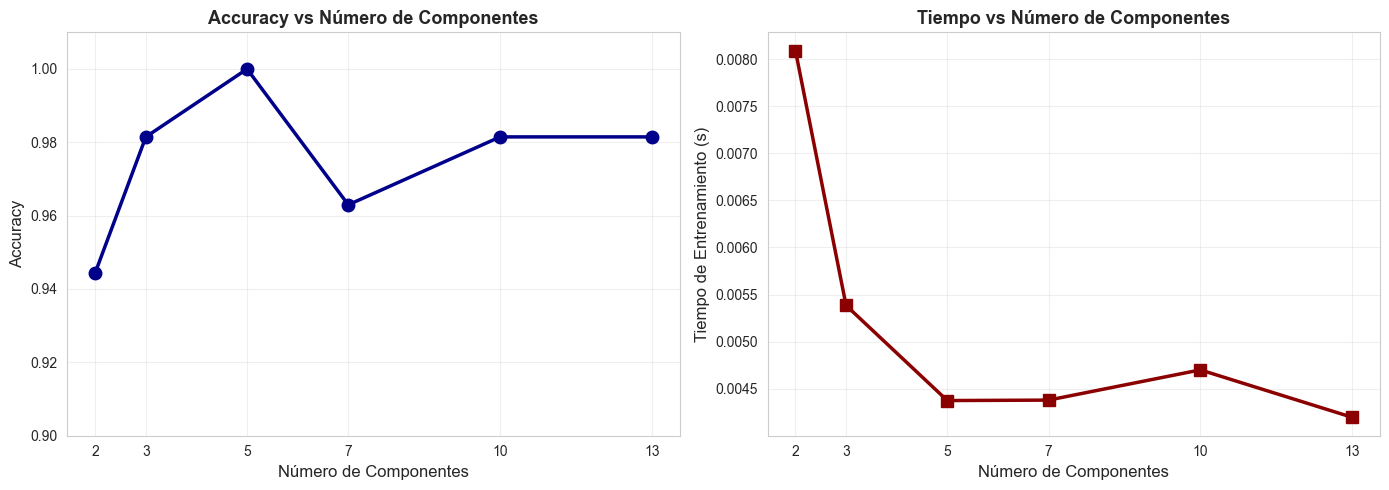


Mejor accuracy con 5 componentes: 1.0000


In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(n_components_range, accuracies, marker='o', linewidth=2.5, markersize=9, color='darkblue')
axes[0].set_xlabel('Número de Componentes', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Accuracy vs Número de Componentes', fontsize=13, weight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(n_components_range)
axes[0].set_ylim([0.9, 1.01])

axes[1].plot(n_components_range, tiempos, marker='s', linewidth=2.5, markersize=9, color='darkred')
axes[1].set_xlabel('Número de Componentes', fontsize=12)
axes[1].set_ylabel('Tiempo de Entrenamiento (s)', fontsize=12)
axes[1].set_title('Tiempo vs Número de Componentes', fontsize=13, weight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(n_components_range)

plt.tight_layout()
plt.show()

best_idx = np.argmax(accuracies)
print(f"\nMejor accuracy con {n_components_range[best_idx]} componentes: {accuracies[best_idx]:.4f}")